<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/subseaequipment/multiphase_reservoir_fluid_flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiphase flow of reservoir fluids with NeqSim

This self-contained tutorial connects **compositional PVT** to **steady-state multiphase flowline hydraulics**. A synthetic oil is flashed from reservoir conditions to a producing flowline, characterized at standard conditions, and transported through an inclined, heat-losing pipe with NeqSim's Beggs–Brill implementation. All data are public educational assumptions—not field data or a design guarantee.

In [1]:
import importlib.metadata, importlib.util, subprocess, sys

# One setup cell works in a clean Colab runtime and does not restart the kernel.
if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim==3.16.0"])

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from neqsim.thermo import fluid, TPflash
from neqsim.process import clearProcess, stream, beggs_brill_pipe, runProcess

neqsim_version = importlib.metadata.version("neqsim")
print(f"NeqSim version: {neqsim_version}")
print(f"Python version: {sys.version.split()[0]}")

NeqSim version: 3.16.0
Python version: 3.12.13


## Audience, prerequisites, and learning objectives

**Audience:** production, flow-assurance, reservoir, and process engineers; senior students; and NeqSim users who know basic thermodynamics. **Prerequisites:** mole and mass fractions, absolute pressure, phase equilibrium, the mechanical-energy balance, and elementary Python.

After completing the notebook you can:

1. build a compositional reservoir fluid with an explicit EOS and mixing rule;
2. distinguish reservoir, flowing, and standard-condition states;
3. explain how phase behavior supplies properties to a multiphase correlation;
4. extract pressure, temperature, holdup, density, velocity, and regime profiles;
5. separate hydrostatic and friction/acceleration contributions approximately;
6. test design sensitivities and recognize where a steady-state correlation is insufficient.

In [2]:
case = {
    "reservoir_pressure_bara": 250.0,
    "reservoir_temperature_C": 90.0,
    "inlet_pressure_bara": 80.0,
    "inlet_temperature_C": 35.0,
    "mass_flow_kg_per_h": 10_000.0,
    "length_m": 10_000.0,
    "inside_diameter_m": 0.18,
    "net_elevation_m": 50.0,
    "roughness_m": 50e-6,
    "overall_U_W_per_m2K": 3.0,
    "ambient_temperature_C": 4.0,
}

# Synthetic mol% composition. nC10 is a discrete component, not a fitted plus fraction.
composition_mol_percent = {
    "nitrogen": 0.5, "CO2": 1.0, "methane": 45.0, "ethane": 5.0,
    "propane": 5.0, "i-butane": 2.0, "n-butane": 3.0,
    "i-pentane": 2.0, "n-pentane": 2.0, "n-hexane": 5.0,
    "n-heptane": 8.0, "n-octane": 10.0, "n-nonane": 6.0, "nC10": 5.5,
}
composition_sum = sum(composition_mol_percent.values())
assert abs(composition_sum - 100.0) < 1e-12
pd.Series(case, name="SI value").to_frame()

,SI value
reservoir_pressure_bara,250.00000
reservoir_temperature_C,90.00000
inlet_pressure_bara,80.00000
inlet_temperature_C,35.00000
mass_flow_kg_per_h,10000.00000
length_m,10000.00000
inside_diameter_m,0.18000
net_elevation_m,50.00000
roughness_m,0.00005
overall_U_W_per_m2K,3.00000


## Compositional PVT model and assumptions

NeqSim represents the fluid as components, mole amounts, an equation of state, mixing rules, phases, and a thermodynamic state. We choose the **Peng–Robinson (PR) cubic EOS** with the classic mixing rule because it is a transparent, commonly used screening model for hydrocarbon mixtures. A real field study should characterize C7+ with measured molecular weight/density, tune binary interactions to PVT data, and quantify uncertainty.

For a TP flash, NeqSim minimizes the appropriate equilibrium criterion subject to material balance and equality of component fugacity between phases:

\[
f_i^{(g)}(T,P,\mathbf{x})=f_i^{(o)}(T,P,\mathbf{x}),\qquad
z_i=\sum_\alpha \beta_\alpha x_{i,\alpha}.
\]

Pressures are absolute (`bara`), temperatures are degrees Celsius at the API boundary and kelvin internally, mass flow is kg/h, and geometric quantities are SI.

In [3]:
def make_reservoir_fluid(flow_kg_h=case["mass_flow_kg_per_h"], methane_mol_percent=45.0):
    comp = composition_mol_percent.copy()
    # Composition sensitivity replaces n-octane with methane and preserves 100 mol%.
    delta = methane_mol_percent - composition_mol_percent["methane"]
    comp["methane"] = methane_mol_percent
    comp["n-octane"] -= delta
    assert comp["n-octane"] > 0 and abs(sum(comp.values()) - 100.0) < 1e-12

    system = fluid("pr")
    for component, mol_percent in comp.items():
        system.addComponent(component, mol_percent)
    system.setMixingRule("classic")
    system.setMultiPhaseCheck(True)
    system.setPressure(case["reservoir_pressure_bara"], "bara")
    system.setTemperature(case["reservoir_temperature_C"], "C")
    system.setTotalFlowRate(flow_kg_h, "kg/hr")
    TPflash(system)
    system.initProperties()
    return system

def flash_to_flowline(reservoir_system, pressure_bara=case["inlet_pressure_bara"], temperature_C=case["inlet_temperature_C"]):
    flowing = reservoir_system.clone()
    flowing.setPressure(pressure_bara, "bara")
    flowing.setTemperature(temperature_C, "C")
    TPflash(flowing)
    flowing.initProperties()
    return flowing

reservoir_fluid = make_reservoir_fluid()
flowing_fluid = flash_to_flowline(reservoir_fluid)
print(f"Reservoir phases at 250 bara and 90 degC: {reservoir_fluid.getNumberOfPhases()}")
print(f"Flowline-inlet phases at 80 bara and 35 degC: {flowing_fluid.getNumberOfPhases()}")

Reservoir phases at 250 bara and 90 degC: 1
Flowline-inlet phases at 80 bara and 35 degC: 2


## Phase split and properties at the flowline inlet

Pressure reduction and cooling move the composition into the gas–oil region. The TP flash determines phase amounts and compositions; `initProperties()` then calculates density, viscosity, enthalpy, and other transport properties required by the hydraulic model. This ordering matters: a pipe correlation cannot be reliable if it receives stale phase properties.

The phase mass rates below must sum to the imposed 10,000 kg/h. Density is kg/m³, viscosity is mPa·s (numerically equal to cP), and actual volume rate is evaluated at the flowing state—not standard conditions.

In [4]:
phase_rows = []
for index in range(flowing_fluid.getNumberOfPhases()):
    phase = flowing_fluid.getPhase(index)
    phase_rows.append({
        "phase": str(phase.getPhaseTypeName()),
        "mass flow [kg/h]": phase.getFlowRate("kg/hr"),
        "mass fraction [-]": phase.getFlowRate("kg/hr") / case["mass_flow_kg_per_h"],
        "actual volume [m3/h]": phase.getFlowRate("m3/hr"),
        "density [kg/m3]": phase.getDensity("kg/m3"),
        "viscosity [mPa s]": phase.getViscosity("cP"),
    })
phase_table = pd.DataFrame(phase_rows).set_index("phase")
phase_mass_closure = phase_table["mass flow [kg/h]"].sum() / case["mass_flow_kg_per_h"]
display(phase_table.round(4))
print(f"Phase mass closure: {phase_mass_closure:.12f} [-]")

       mass flow [kg/h]  mass fraction [-]  ...  density [kg/m3]  viscosity [mPa s]
phase                                       ...                                    
gas            836.8988             0.0837  ...          69.7963             0.0138
oil           9163.1012             0.9163  ...         592.1448             0.2158

[2 rows x 5 columns]
Phase mass closure: 1.000000000000 [-]


## Standard-condition characterization and GOR

Black-oil quantities are useful summaries, but the pipe still uses the full compositional fluid. We flash a **clone** to 15 °C and 1.01325 bara, leaving the flowing object unchanged. The producing gas–oil ratio is

\[
GOR=\frac{Q_{g,std}}{Q_{o,stock}},
\]

reported as standard cubic metres of gas per stock-tank cubic metre of oil. Standard-condition conventions vary by company and jurisdiction, so always state them. This single-stage educational flash is not a substitute for a laboratory differential-liberation or separator test.

In [5]:
surface_fluid = flowing_fluid.clone()
surface_fluid.setPressure(1.01325, "bara")
surface_fluid.setTemperature(15.0, "C")
TPflash(surface_fluid)
surface_fluid.initProperties()

surface_gas_Sm3_per_day = surface_fluid.getPhase("gas").getFlowRate("Sm3/day")
stock_tank_oil_m3_per_day = surface_fluid.getPhase("oil").getFlowRate("m3/hr") * 24.0
surface_GOR_Sm3_per_m3 = surface_gas_Sm3_per_day / stock_tank_oil_m3_per_day
surface_summary = pd.Series({
    "surface gas [Sm3/day]": surface_gas_Sm3_per_day,
    "stock-tank oil [m3/day]": stock_tank_oil_m3_per_day,
    "producing GOR [Sm3/m3]": surface_GOR_Sm3_per_m3,
    "stock-tank oil density [kg/m3]": surface_fluid.getPhase("oil").getDensity("kg/m3"),
})
surface_summary.to_frame("value").round(3)

,value
surface gas [Sm3/day],63487.435
stock-tank oil [m3/day],245.868
producing GOR [Sm3/m3],258.218
stock-tank oil density [kg/m3],691.565


## Beggs–Brill steady-state flow model

The one-dimensional mechanical-energy balance is commonly written

\[
\frac{dP}{dL}=\left(\frac{dP}{dL}\right)_{friction}
+\rho_m g\sin\theta
+\left(\frac{dP}{dL}\right)_{acceleration}.
\]

Beggs–Brill uses no-slip liquid fraction, mixture Froude number, empirical regime boundaries, horizontal holdup, and an inclination correction. NeqSim flashes the compositional fluid along the pipe, updates phase properties, evaluates the correlation segment by segment, and couples heat loss through an overall heat-transfer coefficient. The stream remains composable with downstream NeqSim unit operations.

The correlation is a screening model: it does not resolve terrain-induced severe slugging, transient liquid accumulation, emulsion rheology, sand, wax deposition, hydrate kinetics, or detailed oil–water slip.

In [6]:
def simulate_line(flow_kg_h=case["mass_flow_kg_per_h"], diameter_m=case["inside_diameter_m"],
                  elevation_m=case["net_elevation_m"], roughness_m=case["roughness_m"],
                  U_W_per_m2K=case["overall_U_W_per_m2K"], methane_mol_percent=45.0):
    reservoir = make_reservoir_fluid(flow_kg_h, methane_mol_percent)
    inlet_fluid = flash_to_flowline(reservoir)
    clearProcess()
    inlet = stream("reservoir-fluid flowline inlet", inlet_fluid)
    pipe = beggs_brill_pipe("production flowline", inlet, case["length_m"], diameter_m, elevation_m, roughness_m)
    pipe.setHeatTransferCoefficient(U_W_per_m2K)
    pipe.setAmbientTemperature(case["ambient_temperature_C"] + 273.15)  # API expects kelvin
    runProcess()
    return {"inlet": inlet, "pipe": pipe, "outlet": pipe.getOutletStream()}

base = simulate_line()
base_line = base["pipe"]
base_summary = pd.Series({
    "inlet pressure [bara]": case["inlet_pressure_bara"],
    "outlet pressure [bara]": base_line.getOutletPressure(),
    "pressure drop [bar]": base_line.getPressureDrop(),
    "outlet temperature [degC]": base["outlet"].getTemperature("C"),
    "outlet flow [kg/h]": base["outlet"].getFlowRate("kg/hr"),
    "outlet regime": str(base_line.getFlowRegime()),
})
base_summary.to_frame("value")

,value
inlet pressure [bara],80.0
outlet pressure [bara],77.044749
pressure drop [bar],2.955251
outlet temperature [degC],16.635863
outlet flow [kg/h],10000.0
outlet regime,TRANSITION


## Inspect segment profiles, not only the outlet

An acceptable outlet pressure can conceal a local problem. We therefore inspect every calculation station. Liquid holdup \(H_L\) is the fraction of pipe volume occupied by liquid and must satisfy \(0\le H_L\le1\). Superficial velocity is the phase volumetric rate divided by the full pipe area; gas and liquid values do not individually include the occupied-area correction.

Cooling shrinks the gas, promotes additional liquid dropout, and changes density and holdup. These coupled property changes are why an EOS flash and a multiphase correlation should be solved together.

In [7]:
length_km = np.asarray(base_line.getLengthProfile(), dtype=float) / 1000.0
pressure_bara = np.asarray(base_line.getPressureProfile(), dtype=float)
temperature_C = np.asarray(base_line.getTemperatureProfile(), dtype=float) - 273.15
holdup = np.asarray(base_line.getLiquidHoldupProfile(), dtype=float)
vsg = np.asarray(base_line.getGasSuperficialVelocityProfile(), dtype=float)
vsl = np.asarray(base_line.getLiquidSuperficialVelocityProfile(), dtype=float)
mixture_density = np.asarray(base_line.getMixtureDensityProfile(), dtype=float)
regimes = [str(x) for x in base_line.getFlowRegimeProfileList()]

profile_table = pd.DataFrame({
    "distance [km]": length_km, "pressure [bara]": pressure_bara,
    "temperature [degC]": temperature_C, "liquid holdup [-]": holdup,
    "gas superficial velocity [m/s]": vsg, "liquid superficial velocity [m/s]": vsl,
    "mixture density [kg/m3]": mixture_density, "flow regime": regimes,
})
profile_table.round(4)

,distance [km],pressure [bara],temperature [degC],liquid holdup [-],gas superficial velocity [m/s],liquid superficial velocity [m/s],mixture density [kg/m3],flow regime
0,0.0,80.0000,35.0000,0.8972,0.1309,0.1689,364.0994,TRANSITION
1,2.0,79.4289,27.3010,0.9220,0.1191,0.1690,378.8524,TRANSITION
2,4.0,78.8429,22.5270,0.9368,0.1125,0.1690,387.7959,TRANSITION
3,6.0,78.2477,19.5774,0.9445,0.1091,0.1690,392.5660,TRANSITION
4,8.0,77.6475,17.7577,0.9474,0.1079,0.1688,394.5116,TRANSITION
5,10.0,77.0447,16.6359,0.9471,0.1080,0.1686,394.6164,TRANSITION


## Pressure-gradient decomposition and an independent screen

The pipe reports the total pressure change. As an independent scale check, approximate the hydrostatic contribution with the length-averaged mixture density:

\[
\Delta P_h\approx \bar\rho_m g\Delta z.
\]

Subtracting this from the total gives a residual containing friction, acceleration, and differences caused by segment-wise property variation. The residual is not a replacement correlation; it checks sign and order of magnitude. For uphill flow both total and hydrostatic contributions should be positive.

In [8]:
g_m_per_s2 = 9.80665
average_mixture_density = np.trapezoid(mixture_density, length_km) / (length_km[-1] - length_km[0])
hydrostatic_screen_bar = average_mixture_density * g_m_per_s2 * case["net_elevation_m"] / 1e5
total_drop_bar = base_line.getPressureDrop()
friction_acceleration_residual_bar = total_drop_bar - hydrostatic_screen_bar
segment_drop_sum_bar = np.asarray(base_line.getPressureDropProfile(), dtype=float)[1:].sum()

gradient_screen = pd.Series({
    "total pressure drop [bar]": total_drop_bar,
    "hydrostatic screen [bar]": hydrostatic_screen_bar,
    "friction + acceleration residual [bar]": friction_acceleration_residual_bar,
    "sum of NeqSim segment drops [bar]": segment_drop_sum_bar,
    "average mixture density [kg/m3]": average_mixture_density,
})
gradient_screen.to_frame("value").round(5)

,value
total pressure drop [bar],2.95525
hydrostatic screen [bar],1.89571
friction + acceleration residual [bar],1.05954
sum of NeqSim segment drops [bar],2.95525
average mixture density [kg/m3],386.61677


## Flow regime, slip, and velocity screening

Flow regime affects holdup and therefore hydrostatic head. The base case remains in the Beggs–Brill transition region along the line. The gas superficial velocity falls as the stream cools and contracts, whereas the liquid velocity changes little. NeqSim also provides an API RP 14E-style erosional-velocity screen.

That screen is only a preliminary indicator. Materials, solids, droplets, corrosion, fittings, vibration, noise, and operator limits can govern at lower velocities. A steady-state regime label is not a slug-frequency prediction.

In [9]:
velocity_summary = pd.Series({
    "inlet gas superficial velocity [m/s]": vsg[0],
    "outlet gas superficial velocity [m/s]": vsg[-1],
    "inlet liquid superficial velocity [m/s]": vsl[0],
    "outlet liquid superficial velocity [m/s]": vsl[-1],
    "reported mixture velocity [m/s]": base_line.getMixtureVelocity(),
    "erosional screening velocity [m/s]": base_line.getErosionalVelocity(),
    "maximum liquid holdup [-]": holdup.max(),
    "minimum liquid holdup [-]": holdup.min(),
})
display(velocity_summary.to_frame("value").round(5))
display(pd.Series(regimes).value_counts().rename_axis("regime").to_frame("stations"))

                                            value
inlet gas superficial velocity [m/s]      0.13089
outlet gas superficial velocity [m/s]     0.10804
inlet liquid superficial velocity [m/s]   0.16892
outlet liquid superficial velocity [m/s]  0.16859
reported mixture velocity [m/s]           0.27662
erosional screening velocity [m/s]        4.17436
maximum liquid holdup [-]                 0.94736
minimum liquid holdup [-]                 0.89715
            stations
regime              
TRANSITION         6


## Thermal sensitivity: insulation and ambient cooling

The overall heat-transfer coefficient \(U\) aggregates internal film, wall, coating/insulation, and external film resistances. For a cylindrical segment, NeqSim applies a heat-loss relation of the form

\[
\dot Q=U A\,(T_{fluid}-T_{ambient}).
\]

`U=0` represents the adiabatic limiting case. Larger values represent weaker insulation or stronger external heat transfer. The case uses a uniform 4 °C ambient; a real route may need burial, seawater, soil, and local bathymetry profiles.

In [10]:
thermal_rows = []
for U in [0.0, 1.0, 3.0, 6.0, 10.0]:
    result = simulate_line(U_W_per_m2K=U)
    thermal_rows.append({
        "overall U [W/(m2 K)]": U,
        "outlet temperature [degC]": result["outlet"].getTemperature("C"),
        "pressure drop [bar]": result["pipe"].getPressureDrop(),
        "outlet holdup [-]": float(result["pipe"].getLiquidHoldupProfile()[-1]),
    })
thermal_table = pd.DataFrame(thermal_rows)
thermal_table.round(4)

,overall U [W/(m2 K)],outlet temperature [degC],pressure drop [bar],outlet holdup [-]
0,0.0,34.7400,2.8388,0.8746
1,1.0,23.6543,2.8942,0.9169
2,3.0,16.6359,2.9553,0.9471
3,6.0,15.0787,2.9914,0.9540
4,10.0,14.9307,3.0079,0.9546


## Diameter sensitivity: isolate friction on a horizontal adiabatic line

Diameter changes velocity, Froude number, regime, holdup, and friction simultaneously. To expose the expected friction limit, this sweep sets net elevation and heat transfer to zero. In the selected validated range, larger diameter lowers horizontal pressure loss.

For an inclined liquid-rich line, the optimum need not follow this simple trend: a larger pipe can increase holdup and hydrostatic head. Diameter selection must therefore use the actual route and the correlation's validity range, followed by higher-fidelity verification.

In [11]:
diameter_rows = []
for diameter in [0.12, 0.14, 0.16, 0.18, 0.20]:
    result = simulate_line(diameter_m=diameter, elevation_m=0.0, U_W_per_m2K=0.0)
    diameter_rows.append({
        "inside diameter [m]": diameter,
        "horizontal pressure drop [bar]": result["pipe"].getPressureDrop(),
        "maximum holdup [-]": max(result["pipe"].getLiquidHoldupProfile()),
        "mixture velocity [m/s]": result["pipe"].getMixtureVelocity(),
        "regime": str(result["pipe"].getFlowRegime()),
    })
diameter_table = pd.DataFrame(diameter_rows)
diameter_table.round(4)

,inside diameter [m],horizontal pressure drop [bar],maximum holdup [-],mixture velocity [m/s],regime
0,0.12,1.8006,0.6319,0.6886,INTERMITTENT
1,0.14,0.8031,0.6904,0.5001,TRANSITION
2,0.16,0.3854,0.8100,0.3811,TRANSITION
3,0.18,0.2148,0.8972,0.3005,TRANSITION
4,0.20,0.1268,0.9659,0.2432,TRANSITION


## Throughput sensitivity and hydraulic capacity

With geometry, composition, and temperature fixed, increasing mass flow raises superficial velocities and horizontal friction loss. We again use the adiabatic horizontal limit so elevation and cooling do not obscure the trend. A capacity study should also impose arrival pressure, erosional velocity, slugging, temperature, hydrate/wax, separator, and compression constraints.

The sweep is intentionally local (8–14 t/h). Extrapolation beyond calibrated ranges can cross regime boundaries and produce non-smooth empirical-correlation behavior.

In [12]:
rate_rows = []
for flow_kg_h in [8_000.0, 10_000.0, 12_000.0, 14_000.0]:
    result = simulate_line(flow_kg_h=flow_kg_h, elevation_m=0.0, U_W_per_m2K=0.0)
    rate_rows.append({
        "mass flow [kg/h]": flow_kg_h,
        "horizontal pressure drop [bar]": result["pipe"].getPressureDrop(),
        "maximum holdup [-]": max(result["pipe"].getLiquidHoldupProfile()),
        "mixture velocity [m/s]": result["pipe"].getMixtureVelocity(),
    })
rate_table = pd.DataFrame(rate_rows)
rate_table.round(4)

,mass flow [kg/h],horizontal pressure drop [bar],maximum holdup [-],mixture velocity [m/s]
0,8000.0,0.1410,0.9558,0.2402
1,10000.0,0.2148,0.8972,0.3005
2,12000.0,0.3031,0.8448,0.3610
3,14000.0,0.4018,0.7963,0.4216


## Elevation and terrain sensitivity

Elevation changes hydrostatic head approximately with \(\rho_m g\Delta z\), but the mixture density itself depends on pressure, temperature, and holdup. Negative net elevation can produce pressure recovery, shown as a negative total drop. A single net elevation is useful for teaching but cannot represent low points, riser bases, or terrain-induced liquid accumulation.

Detailed design should use a route profile with sufficient segmentation and a transient multiphase model when liquid inventory or severe slugging matters.

In [13]:
elevation_rows = []
for elevation in [-50.0, 0.0, 50.0, 100.0]:
    result = simulate_line(elevation_m=elevation, U_W_per_m2K=0.0)
    elevation_rows.append({
        "net elevation [m]": elevation,
        "total pressure drop [bar]": result["pipe"].getPressureDrop(),
        "outlet pressure [bara]": result["pipe"].getOutletPressure(),
        "maximum holdup [-]": max(result["pipe"].getLiquidHoldupProfile()),
    })
elevation_table = pd.DataFrame(elevation_rows)
elevation_table.round(4)

,net elevation [m],total pressure drop [bar],outlet pressure [bara],maximum holdup [-]
0,-50.0,-2.4436,82.4436,0.9161
1,0.0,0.2148,79.7852,0.8972
2,50.0,2.8388,77.1612,0.8972
3,100.0,5.4267,74.5733,0.8972


## Roughness and uncertainty sensitivity

Absolute roughness enters the friction calculation through relative roughness \(\varepsilon/D\). The 50 µm base value is a stated educational assumption for a comparatively smooth line; corrosion, deposits, internal coating, and age can change it. The horizontal adiabatic sweep confirms that greater roughness increases predicted loss.

Roughness is only one uncertainty. Fluid characterization, viscosity, phase envelope, route elevation, heat-transfer coefficient, operating rate, and the correlation itself should be included in an engineering uncertainty envelope.

In [14]:
roughness_rows = []
for roughness in [1e-6, 50e-6, 200e-6, 1e-3]:
    result = simulate_line(roughness_m=roughness, elevation_m=0.0, U_W_per_m2K=0.0)
    roughness_rows.append({
        "absolute roughness [m]": roughness,
        "relative roughness [-]": roughness / case["inside_diameter_m"],
        "horizontal pressure drop [bar]": result["pipe"].getPressureDrop(),
    })
roughness_table = pd.DataFrame(roughness_rows)
roughness_table.round(6)

,absolute roughness [m],relative roughness [-],horizontal pressure drop [bar]
0,0.000001,0.000006,0.195702
1,0.000050,0.000278,0.214837
2,0.000200,0.001111,0.259351
3,0.001000,0.005556,0.382748


## Fluid richness sensitivity: connect PVT and hydraulics

Changing composition alters standard GOR, phase split, density, viscosity, gas expansion, holdup, and pressure loss. To make the perturbation explicit, methane replaces the same molar amount of n-octane while all other components remain fixed. This is a scenario—not a claim that real fluids evolve along this artificial path.

The surface flash provides an interpretable GOR, while the full compositional fluid is retained in the flowline. This illustrates why black-oil summaries alone cannot reproduce all compositional hydraulic effects.

In [15]:
richness_rows = []
for methane_mol_percent in [45.0, 46.25, 47.5, 48.75, 50.0]:
    reservoir = make_reservoir_fluid(methane_mol_percent=methane_mol_percent)
    flowing = flash_to_flowline(reservoir)
    surface = flowing.clone(); surface.setPressure(1.01325, "bara"); surface.setTemperature(15.0, "C")
    TPflash(surface); surface.initProperties()
    gor = surface.getPhase("gas").getFlowRate("Sm3/day") / (24.0 * surface.getPhase("oil").getFlowRate("m3/hr"))
    result = simulate_line(methane_mol_percent=methane_mol_percent)
    richness_rows.append({
        "methane [mol%]": methane_mol_percent,
        "n-octane [mol%]": composition_mol_percent["n-octane"] - (methane_mol_percent - 45.0),
        "surface GOR [Sm3/m3]": gor,
        "pressure drop [bar]": result["pipe"].getPressureDrop(),
        "maximum holdup [-]": max(result["pipe"].getLiquidHoldupProfile()),
    })
richness_table = pd.DataFrame(richness_rows)
richness_table.round(4)

,methane [mol%],n-octane [mol%],surface GOR [Sm3/m3],pressure drop [bar],maximum holdup [-]
0,45.00,10.00,258.2179,2.9553,0.9474
1,46.25,8.75,275.1545,2.8868,0.9198
2,47.50,7.50,293.5895,2.8201,0.8927
3,48.75,6.25,313.7374,2.7552,0.8662
4,50.00,5.00,335.8557,2.6918,0.8402


## Visual engineering interpretation

The four plots connect local profiles with controlled sensitivities. A reviewer should look for smoothness, correct boundary values, physical bounds, and understandable trends—not merely attractive curves. Sudden changes can be real regime transitions, numerical artifacts, or operation outside a correlation's range and deserve investigation.

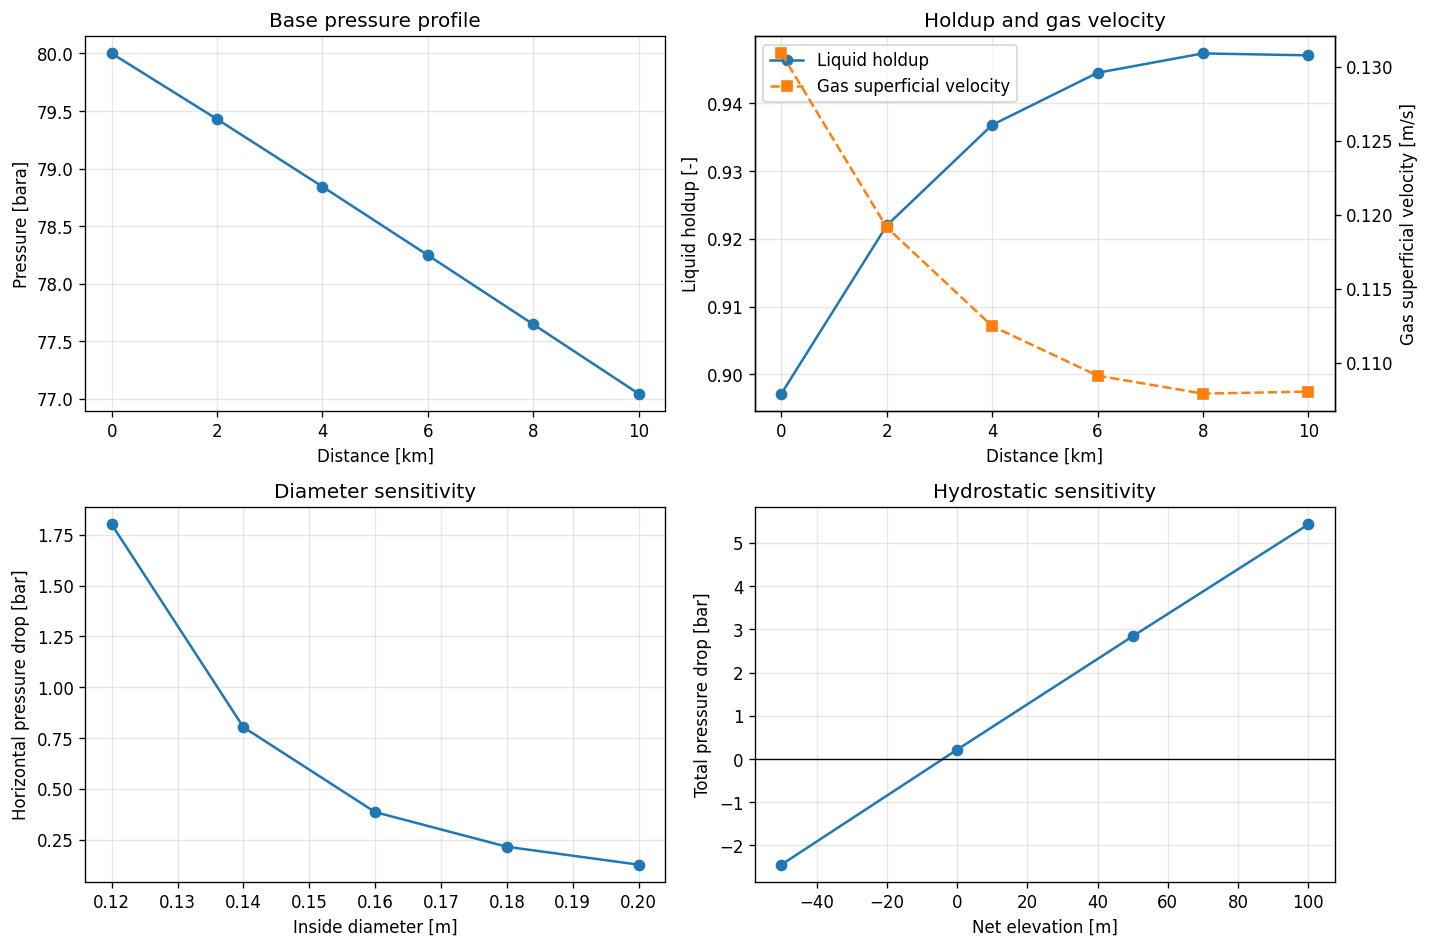

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(length_km, pressure_bara, "o-")
axes[0, 0].set(xlabel="Distance [km]", ylabel="Pressure [bara]", title="Base pressure profile")
holdup_line = axes[0, 1].plot(length_km, holdup, "o-", color="tab:blue", label="Liquid holdup")
axes[0, 1].set(xlabel="Distance [km]", ylabel="Liquid holdup [-]", title="Holdup and gas velocity")
velocity_axis = axes[0, 1].twinx()
velocity_line = velocity_axis.plot(length_km, vsg, "s--", color="tab:orange", label="Gas superficial velocity")
velocity_axis.set_ylabel("Gas superficial velocity [m/s]")
axes[0, 1].legend(holdup_line + velocity_line, [line.get_label() for line in holdup_line + velocity_line])
axes[1, 0].plot(diameter_table["inside diameter [m]"], diameter_table["horizontal pressure drop [bar]"], "o-")
axes[1, 0].set(xlabel="Inside diameter [m]", ylabel="Horizontal pressure drop [bar]", title="Diameter sensitivity")
axes[1, 1].plot(elevation_table["net elevation [m]"], elevation_table["total pressure drop [bar]"], "o-")
axes[1, 1].axhline(0.0, color="black", linewidth=0.8)
axes[1, 1].set(xlabel="Net elevation [m]", ylabel="Total pressure drop [bar]", title="Hydrostatic sensitivity")
for ax in axes.flat: ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Verification, troubleshooting, and validity limits

The executable checks below provide evidence level 3–4: conservation/consistency plus expected limiting trends. They are not a published experimental benchmark. Common problems and remedies:

- **One phase at the inlet:** verify pressure, temperature, composition, and `setMultiPhaseCheck(True)`; phase behavior may genuinely be single phase.
- **Uninitialized properties:** run `TPflash` and `initProperties()` before creating the stream.
- **Implausible holdup or discontinuous trends:** reduce the scenario range, inspect Froude number/regime, increase segmentation where supported, and compare another correlation or transient model. Holdup must remain within [0,1].
- **Unexpected temperature:** `setAmbientTemperature` uses kelvin in this API; the notebook converts from °C explicitly.
- **Non-convergence or nonpositive outlet pressure:** shorten the line, increase diameter or inlet pressure, reduce flow, and approach the target incrementally.

Validity is limited by PR EOS characterization, synthetic composition, steady state, a uniform pipe and ambient, empirical Beggs–Brill range, and no oil–water/emulsion/solids/deposition physics. Do not use this educational case as a certified design.

In [17]:
base_repeat = simulate_line()
checks = {
    "composition closes": abs(composition_sum - 100.0) < 1e-12,
    "reservoir is single phase": reservoir_fluid.getNumberOfPhases() == 1,
    "flowline inlet is gas-oil two phase": flowing_fluid.getNumberOfPhases() == 2,
    "phase mass closes": abs(phase_mass_closure - 1.0) < 1e-10,
    "surface GOR is plausible for the synthetic oil": 100.0 < surface_GOR_Sm3_per_m3 < 500.0,
    "pipe mass closes": abs(base["inlet"].getFlowRate("kg/hr") - base["outlet"].getFlowRate("kg/hr")) < 1e-6,
    "pressure profile decreases": np.all(np.diff(pressure_bara) < 0.0),
    "temperature stays between ambient and inlet": temperature_C.min() > case["ambient_temperature_C"] and temperature_C.max() <= case["inlet_temperature_C"] + 1e-9,
    "holdup is physical": np.all((holdup >= 0.0) & (holdup <= 1.0)),
    "superficial velocities are positive": np.all(vsg > 0.0) and np.all(vsl > 0.0),
    "segment drops sum to total": abs(segment_drop_sum_bar - total_drop_bar) < 1e-8,
    "uphill hydrostatic and residual terms are positive": hydrostatic_screen_bar > 0.0 and friction_acceleration_residual_bar > 0.0,
    "stronger cooling lowers outlet temperature": np.all(np.diff(thermal_table["outlet temperature [degC]"]) < 0.0),
    "larger horizontal diameter lowers friction loss": np.all(np.diff(diameter_table["horizontal pressure drop [bar]"]) < 0.0),
    "horizontal friction rises with throughput": np.all(np.diff(rate_table["horizontal pressure drop [bar]"]) > 0.0),
    "pressure drop rises with elevation": np.all(np.diff(elevation_table["total pressure drop [bar]"]) > 0.0),
    "pressure drop rises with roughness": np.all(np.diff(roughness_table["horizontal pressure drop [bar]"]) > 0.0),
    "GOR rises with methane enrichment": np.all(np.diff(richness_table["surface GOR [Sm3/m3]"]) > 0.0),
    "base cases stay inside holdup bounds": max(diameter_table["maximum holdup [-]"].max(), rate_table["maximum holdup [-]"].max(), elevation_table["maximum holdup [-]"].max(), richness_table["maximum holdup [-]"].max()) <= 1.0,
    "mixture velocity is below erosional screen": base_line.getMixtureVelocity() < base_line.getErosionalVelocity(),
    "repeat run is deterministic": abs(base_repeat["pipe"].getPressureDrop() - base_line.getPressureDrop()) < 1e-9,
}
assert all(checks.values()), {name: ok for name, ok in checks.items() if not ok}
pd.Series(checks, name="passed").to_frame()

,passed
composition closes,True
reservoir is single phase,True
flowline inlet is gas-oil two phase,True
phase mass closes,True
surface GOR is plausible for the synthetic oil,True
pipe mass closes,True
pressure profile decreases,True
temperature stays between ambient and inlet,True
holdup is physical,True
superficial velocities are positive,True


## Summary, further exercises, and authoritative references

**Summary.** NeqSim keeps one compositional fluid object through reservoir, flowing, and standard-condition flashes. The PR EOS supplies phase split and properties; a named inlet stream feeds `beggs_brill_pipe`; the pipe solves successive thermodynamic and hydraulic states; and profiles expose pressure, temperature, holdup, velocities, density, and regime. The base 10 km, 0.18 m ID, 50 m uphill case is validated by mass closure, pressure-drop reconstruction, a hydrostatic screen, repeatability, physical bounds, and controlled sensitivity trends.

**Further exercises.** (1) Replace the discrete heavy components with a characterized C7+ fraction and compare GOR. (2) Import a route elevation profile and identify liquid-accumulation risks. (3) Compare Beggs–Brill with Mukherjee–Brill or a two-fluid model over a stated validity envelope. (4) Add a host separator using the pipe outlet stream and verify component balances. (5) Propagate uncertainty in viscosity, roughness, U, and composition with Monte Carlo sampling. (6) Add water with a suitable association model, explicitly checking three-phase applicability and oil–water slip limitations.

**References.** Beggs, H.D. & Brill, J.P. (1973), “A Study of Two-Phase Flow in Inclined Pipes,” *Journal of Petroleum Technology*, [doi:10.2118/4007-PA](https://doi.org/10.2118/4007-PA). Brill, J.P. & Mukherjee, H. (1999), *Multiphase Flow in Wells*. [NeqSim documentation](https://equinor.github.io/neqsimhome/) and [Beggs–Brill implementation guide](https://github.com/equinor/neqsim/blob/master/docs/wiki/beggs_and_brill_correlation.md). API RP 14E, *Recommended Practice for Design and Installation of Offshore Production Platform Piping Systems*. ISO 13628-1, *Petroleum and natural gas industries—Design and operation of subsea production systems*.

In [18]:
result_record = {
    "neqsim_version": neqsim_version,
    "fluid_model": "Peng-Robinson EOS with classic mixing rule",
    "surface_GOR_Sm3_per_m3": round(surface_GOR_Sm3_per_m3, 2),
    "flowline_outlet_pressure_bara": round(base_line.getOutletPressure(), 4),
    "flowline_outlet_temperature_C": round(base["outlet"].getTemperature("C"), 3),
    "flowline_pressure_drop_bar": round(base_line.getPressureDrop(), 5),
    "maximum_liquid_holdup": round(float(holdup.max()), 5),
    "flow_regime": str(base_line.getFlowRegime()),
    "validated_checks": len(checks),
}
pd.Series(result_record, name="validated result").to_frame()

,validated result
neqsim_version,3.16.0
fluid_model,Peng-Robinson EOS with classic mixing rule
surface_GOR_Sm3_per_m3,258.22
flowline_outlet_pressure_bara,77.0447
flowline_outlet_temperature_C,16.636
flowline_pressure_drop_bar,2.95525
maximum_liquid_holdup,0.94736
flow_regime,TRANSITION
validated_checks,21
